# CRISP-DM Notebook: Predicting `orders.is_fraud`

This notebook builds a full machine learning pipeline to predict fraud from the operational database (Postgres/Supabase **or** local `shop.db`), following CRISP-DM and Chapters 1-17 course skills.

## Scope
- Target: `orders.is_fraud`
- Source: **Local:** `shop.db` in the project root (default). **Cloud:** set `DATABASE_URL` to `postgresql://...`
- Modeling goal: compare multiple classifiers and select a deployable fraud model
- Decision metrics: `F1`, `PR-AUC`, and `Recall` (with threshold analysis)

## Chapter Coverage Map
- **Ch 1**: Project framing via CRISP-DM
- **Ch 2-4**: Data wrangling and cleaning
- **Ch 6**: Feature-level exploration
- **Ch 7**: Automated preparation pipelines
- **Ch 8**: Relationship discovery
- **Ch 13**: Classification modeling
- **Ch 14**: Ensemble methods
- **Ch 15**: Evaluation, selection, and tuning
- **Ch 16**: Feature selection
- **Ch 17**: Deployment artifact serialization

In [1]:
import os
import sys
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
_ml_src = ROOT / "ml" / "src"
if str(_ml_src) not in sys.path:
    sys.path.insert(0, str(_ml_src))

from extract_and_clean import get_engine

ENGINE = get_engine()
ARTIFACT_DIR = ROOT / "ml" / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

_u = ENGINE.url
print(f"Connected: {_u.drivername}" + (f" → {_u.database}" if _u.drivername == "sqlite" else f" → {_u.host}/{_u.database}"))

Connected: sqlite → /Users/jooyoung/Downloads/455_class_project/shop.db


## 1) Business Understanding

Fraudulent transactions cause financial loss and operational overhead. The business objective is to flag suspicious orders early so risk teams can review high-risk transactions.

### Success Criteria
- Build a reproducible fraud model pipeline.
- Compare multiple models and select one based on **F1**, **PR-AUC**, and **Recall**.
- Produce deployable artifacts (serialized model + preprocessing + selected threshold).

### Modeling Decision Rule
Because fraud is typically imbalanced, we will prioritize:
1. Strong PR-AUC (ranking quality on positives)
2. Sufficient recall (catch fraudulent orders)
3. Good F1 balance for precision/recall tradeoff

In [2]:
# Load operational tables (Postgres or local shop.db)
customers = pd.read_sql_query("SELECT * FROM customers", ENGINE)
orders = pd.read_sql_query("SELECT * FROM orders", ENGINE)
order_items = pd.read_sql_query("SELECT * FROM order_items", ENGINE)
shipments = pd.read_sql_query("SELECT * FROM shipments", ENGINE)

print("customers", customers.shape)
print("orders", orders.shape)
print("order_items", order_items.shape)
print("shipments", shipments.shape)

orders.head(3)

customers (250, 12)
orders (5001, 17)
order_items (15026, 6)
shipments (5000, 9)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.95,15.44,46.30,724.69,38.3,0
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,94.9,0
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.09,14.04,40.72,850.85,53.8,1


## 2) Data Understanding (Ch. 6 + Ch. 8)

We first inspect quality and target balance, then explore feature distributions and fraud relationships.

In [3]:
# Basic quality checks on orders (target table)
quality = pd.DataFrame({
    "dtype": orders.dtypes.astype(str),
    "null_count": orders.isna().sum(),
    "null_pct": (orders.isna().mean() * 100).round(2),
    "n_unique": orders.nunique(dropna=False)
}).sort_values("null_pct", ascending=False)

print("Target distribution (is_fraud):")
print(orders["is_fraud"].value_counts(dropna=False))
print("Fraud rate:", round(orders["is_fraud"].fillna(0).mean(), 4))
quality.head(20)

Target distribution (is_fraud):
is_fraud
0    4683
1     318
Name: count, dtype: int64
Fraud rate: 0.0636


,dtype,null_count,null_pct,n_unique
promo_code,object,3740,74.79,6
order_id,int64,0,0.00,5001
promo_used,int64,0,0.00,2
risk_score,float64,0,0.00,924
order_total,float64,0,0.00,4858
tax_amount,float64,0,0.00,3451
shipping_fee,float64,0,0.00,33
order_subtotal,float64,0,0.00,4078
ip_country,object,0,0.00,6
customer_id,int64,0,0.00,243


In [4]:
# Same fraud feature frame as extract_and_clean.py / web fraud form (includes actual_days)
import sys

_ml_src = ROOT / "ml" / "src"
if str(_ml_src) not in sys.path:
    sys.path.insert(0, str(_ml_src))

from fraud_features import build_fraud_dataset as build_fraud_dataset_shared

_dfs = {
    "orders": orders,
    "customers": customers,
    "shipments": shipments,
    "order_items": order_items,
}
fraud_df = build_fraud_dataset_shared(_dfs)
print("Fraud modeling dataset:", fraud_df.shape)
fraud_df.head(3)

Fraud modeling dataset: (5001, 28)


,order_id,customer_id,order_total,order_subtotal,shipping_fee,tax_amount,risk_score,payment_method,device_type,ip_country,promo_used,customer_segment,loyalty_tier,gender,state,shipping_state,shipping_method,distance_band,promised_days,actual_days,items_per_order,unique_products,avg_item_price,customer_age,account_age_days,shipping_to_subtotal_ratio,tax_to_subtotal_ratio,is_fraud
0,1,1,724.69,662.95,15.44,46.30,38.3,card,mobile,US,0,standard,silver,Female,CO,CO,expedited,regional,3.0,5.0,9,5,69.242,20.476386,48,0.023290,0.069839,0
1,2,1,944.27,862.92,14.74,66.61,94.9,card,desktop,US,1,standard,silver,Female,CO,NY,expedited,local,2.0,3.0,7,5,133.300,20.232717,0,0.017082,0.077191,0
2,3,1,850.85,796.09,14.04,40.72,53.8,card,mobile,US,0,standard,silver,Female,CO,CO,expedited,national,4.0,8.0,5,3,140.850,20.520192,64,0.017636,0.051150,1


In [5]:
# Automated feature-level exploration (Ch 6)
num_cols = fraud_df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in fraud_df.columns if c not in num_cols]

eda_summary = pd.DataFrame({
    "dtype": fraud_df.dtypes.astype(str),
    "missing_pct": (fraud_df.isna().mean() * 100).round(2),
    "unique": fraud_df.nunique(dropna=False),
})

print("Numeric columns:", len(num_cols), "| Categorical columns:", len(cat_cols))
eda_summary.sort_values(["missing_pct", "unique"], ascending=[False, False]).head(30)

Numeric columns: 18 | Categorical columns: 10


,dtype,missing_pct,unique
order_id,int64,0.0,5001
tax_to_subtotal_ratio,float64,0.0,4977
order_total,float64,0.0,4858
shipping_to_subtotal_ratio,float64,0.0,4147
order_subtotal,float64,0.0,4078
avg_item_price,float64,0.0,3933
tax_amount,float64,0.0,3451
customer_age,float64,0.0,2494
risk_score,float64,0.0,924
account_age_days,int64,0.0,351


In [6]:
# Relationship discovery (Ch 8): fraud rate by key categorical features
for col in ["payment_method", "device_type", "ip_country", "customer_segment", "shipping_method", "distance_band"]:
    rel = (
        fraud_df.groupby(col, dropna=False)["is_fraud"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate"})
        .sort_values("fraud_rate", ascending=False)
    )
    print(f"\n{col} -> top fraud rates")
    display(rel.head(10))


payment_method -> top fraud rates


,fraud_rate,count
payment_method,,
crypto,0.103093,97
card,0.067434,3129
bank,0.059310,725
paypal,0.051429,1050



device_type -> top fraud rates


,fraud_rate,count
device_type,,
mobile,0.068032,2734
tablet,0.065934,364
desktop,0.056782,1902
web,0.000000,1



ip_country -> top fraud rates


...

,fraud_rate,count
customer_segment,,
standard,0.067128,2890
budget,0.062323,1765
premium,0.040462,346



shipping_method -> top fraud rates


,fraud_rate,count
shipping_method,,
overnight,0.079208,303
standard,0.063847,3618
expedited,0.058387,1079
UNKNOWN,0.000000,1



distance_band -> top fraud rates


,fraud_rate,count
distance_band,,
national,0.072727,990
local,0.068765,1716
regional,0.055798,2294
UNKNOWN,0.000000,1


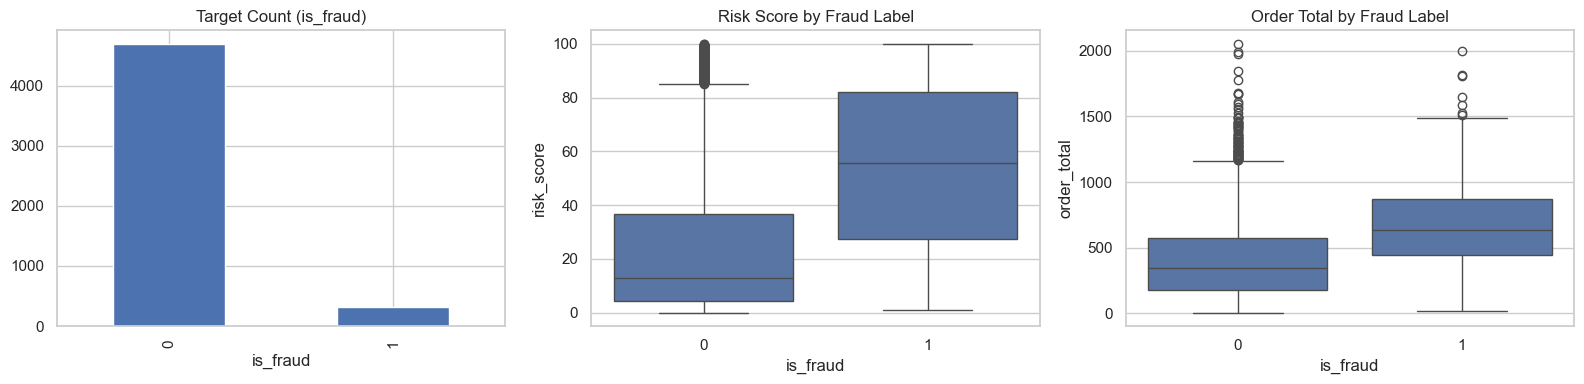

In [7]:
# Quick visual checks: class imbalance and top numeric relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

fraud_df["is_fraud"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Target Count (is_fraud)")
axes[0].set_xlabel("is_fraud")

sns.boxplot(data=fraud_df, x="is_fraud", y="risk_score", ax=axes[1])
axes[1].set_title("Risk Score by Fraud Label")

sns.boxplot(data=fraud_df, x="is_fraud", y="order_total", ax=axes[2])
axes[2].set_title("Order Total by Fraud Label")

plt.tight_layout()
plt.show()

## 3) Data Preparation + Modeling

We create an automated preprocessing pipeline and train multiple classification models:
- Logistic Regression (baseline classifier)
- Random Forest (ensemble, Ch 14)
- Gradient Boosting (ensemble, Ch 14)

Then we tune selected models and compare by F1, PR-AUC, and Recall.

In [8]:
# Train/test split + preprocessing
id_cols = ["order_id", "customer_id"]
target_col = "is_fraud"

X = fraud_df.drop(columns=id_cols + [target_col], errors="ignore")
y = fraud_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_features),
    ]
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Positive class rate (train):", round(y_train.mean(), 4))

Train shape: (4000, 25) | Test shape: (1001, 25)
Positive class rate (train): 0.0635


In [9]:
def score_model(name, model, X_train, y_train, X_test, y_test, threshold=0.5):
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probs),
        "pr_auc": average_precision_score(y_test, probs),
        "cm": confusion_matrix(y_test, preds),
        "probs": probs,
    }

models = {
    "logistic_regression": Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),
    "random_forest": Pipeline([
        ("preprocess", preprocess),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ))
    ]),
    "gradient_boosting": Pipeline([
        ("preprocess", preprocess),
        ("clf", GradientBoostingClassifier(random_state=42))
    ]),
}

baseline_results = []
raw_outputs = {}
for name, model in models.items():
    out = score_model(name, model, X_train, y_train, X_test, y_test, threshold=0.5)
    raw_outputs[name] = out
    baseline_results.append({k: v for k, v in out.items() if k not in ["cm", "probs"]})

baseline_df = pd.DataFrame(baseline_results).sort_values(["pr_auc", "f1", "recall"], ascending=False)
baseline_df

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
2,gradient_boosting,0.5,0.969031,0.883721,0.59375,0.710280,0.949390,0.791761
0,logistic_regression,0.5,0.928072,0.465517,0.84375,0.600000,0.963781,0.777026
1,random_forest,0.5,0.944056,0.833333,0.15625,0.263158,0.932581,0.627256


In [10]:
# Hyperparameter tuning (Ch 15): Random Forest as strong fraud candidate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
])

param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 2, 5],
}

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="average_precision",  # PR-AUC proxy for imbalanced fraud
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
rf_probs = best_rf.predict_proba(X_test)[:, 1]

print("Best params:", grid.best_params_)
print("Best CV PR-AUC:", round(grid.best_score_, 4))

Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
Best CV PR-AUC: 0.6005


In [11]:
# Threshold analysis: optimize for F1 while inspecting PR-AUC/Recall trade-off
threshold_grid = np.round(np.arange(0.05, 0.96, 0.05), 2)
rows = []
for t in threshold_grid:
    preds = (rf_probs >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    })

thr_df = pd.DataFrame(rows)
best_thr_row = thr_df.sort_values(["f1", "recall"], ascending=False).iloc[0]
selected_threshold = float(best_thr_row["threshold"])

final_preds = (rf_probs >= selected_threshold).astype(int)
final_metrics = {
    "threshold": selected_threshold,
    "accuracy": accuracy_score(y_test, final_preds),
    "precision": precision_score(y_test, final_preds, zero_division=0),
    "recall": recall_score(y_test, final_preds, zero_division=0),
    "f1": f1_score(y_test, final_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, rf_probs),
    "pr_auc": average_precision_score(y_test, rf_probs),
}

print("Selected threshold:", selected_threshold)
pd.DataFrame([final_metrics]).T.rename(columns={0: "value"})

Selected threshold: 0.2


,value
threshold,0.200000
accuracy,0.954046
precision,0.640625
recall,0.640625
f1,0.640625
roc_auc,0.927011
pr_auc,0.626579


In [12]:
# Feature selection (Ch 16): SelectFromModel + compare performance
feature_select_pipeline = Pipeline([
    ("preprocess", preprocess),
    (
        "selector",
        SelectFromModel(
            estimator=RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
            threshold="median",
        ),
    ),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
])

fs_out = score_model(
    "feature_select_logistic",
    feature_select_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.5,
)

pd.DataFrame([
    {k: v for k, v in fs_out.items() if k not in ["cm", "probs"]}
]).T.rename(columns={0: "value"})

,value
model,feature_select_logistic
threshold,0.5
accuracy,0.928072
precision,0.467742
recall,0.90625
f1,0.617021
roc_auc,0.967349
pr_auc,0.787699


In [13]:
# Consolidated model comparison table
comparison_rows = baseline_df[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].copy()
comparison_rows = pd.concat([
    comparison_rows,
    pd.DataFrame([
        {
            "model": "random_forest_tuned_thresholded",
            "accuracy": final_metrics["accuracy"],
            "precision": final_metrics["precision"],
            "recall": final_metrics["recall"],
            "f1": final_metrics["f1"],
            "roc_auc": final_metrics["roc_auc"],
            "pr_auc": final_metrics["pr_auc"],
        },
        {
            "model": "feature_select_logistic",
            "accuracy": fs_out["accuracy"],
            "precision": fs_out["precision"],
            "recall": fs_out["recall"],
            "f1": fs_out["f1"],
            "roc_auc": fs_out["roc_auc"],
            "pr_auc": fs_out["pr_auc"],
        },
    ])
], ignore_index=True)

comparison_rows.sort_values(["pr_auc", "f1", "recall"], ascending=False)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,gradient_boosting,0.969031,0.883721,0.593750,0.710280,0.949390,0.791761
4,feature_select_logistic,0.928072,0.467742,0.906250,0.617021,0.967349,0.787699
1,logistic_regression,0.928072,0.465517,0.843750,0.600000,0.963781,0.777026
2,random_forest,0.944056,0.833333,0.156250,0.263158,0.932581,0.627256
3,random_forest_tuned_thresholded,0.954046,0.640625,0.640625,0.640625,0.927011,0.626579


## 4) Evaluation + Selection Decision

Decision approach used:
- Compare all candidate models by **PR-AUC**, **F1**, and **Recall**.
- Use threshold tuning on the top imbalanced-learning candidate.
- Prefer the model-threshold pair with strongest fraud capture quality and stable precision.

Use the table above as your submission evidence, then keep that winning model for deployment.

In [14]:
# Deployment artifacts (Ch 17): serialize model package + metadata
final_model = best_rf
artifact = {
    "model": final_model,
    "selected_threshold": selected_threshold,
    "feature_columns": X_train.columns.tolist(),
    "target": target_col,
    "metrics": final_metrics,
}

artifact_path = ARTIFACT_DIR / "fraud_pipeline_artifact.joblib"
joblib.dump(artifact, artifact_path)

print("Saved artifact:", artifact_path)
print("Selected threshold:", selected_threshold)
print("Final metrics:")
pd.DataFrame([final_metrics])

Saved artifact: /Users/jooyoung/Downloads/455_class_project/ml/models/fraud_pipeline_artifact.joblib
Selected threshold: 0.2
Final metrics:


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.2,0.954046,0.640625,0.640625,0.640625,0.927011,0.626579


In [15]:
# Inference demo: score one sample record
loaded = joblib.load(artifact_path)
model = loaded["model"]
thr = loaded["selected_threshold"]

sample = X_test.iloc[[0]].copy()
prob = float(model.predict_proba(sample)[:, 1][0])
pred = int(prob >= thr)

print("Sample fraud probability:", round(prob, 4))
print("Threshold:", thr)
print("Predicted class:", pred)
sample

Sample fraud probability: 0.0725
Threshold: 0.2
Predicted class: 0


,order_total,order_subtotal,shipping_fee,tax_amount,risk_score,payment_method,device_type,ip_country,promo_used,customer_segment,loyalty_tier,gender,state,shipping_state,shipping_method,distance_band,promised_days,actual_days,items_per_order,unique_products,avg_item_price,customer_age,account_age_days,shipping_to_subtotal_ratio,tax_to_subtotal_ratio
4896,468.12,429.72,8.04,30.36,7.2,paypal,mobile,US,0,budget,none,Male,TX,TX,standard,national,7.0,11.0,5,5,85.944,47.786448,264,0.01871,0.070651


## 4b) Inference on Unscored Records & Writeback Preview

We simulate fetching candidate un-scored records, predicting on them, and formatting the results into the schema expected by the `order_predictions` table for our Supabase writeback contract.

In [ ]:
# Fetch a batch of records (simulating /api/orders/unscored)
# Here we just use our test set `X_test` for brevity.
unscored_batch = X_test.head(5).copy()

# Restore index to access order_id (assuming it was dropped during split)
order_ids = fraud_df.loc[unscored_batch.index, 'order_id'].values

# Perform inference
batch_probs = model.predict_proba(unscored_batch)[:, 1]
batch_preds = (batch_probs >= thr).astype(int)

# Format the write-back payload to match order_predictions schema
writeback_payload = []
for idx, row in enumerate(unscored_batch.to_dict('records')):
    record = {
        "order_id": int(order_ids[idx]),
        "task_name": "fraud",
        "probability": float(batch_probs[idx]),
        "predicted_class": int(batch_preds[idx]),
        "model_threshold": thr,
        "features_json": row
    }
    writeback_payload.append(record)

print(f"Prepared {len(writeback_payload)} records for /api/predictions/upsert writeback")
pd.DataFrame(writeback_payload).head()

## 5) Final Conclusion (for report/submission)

- We implemented a full CRISP-DM fraud pipeline from business framing to deployment artifacts.
- We compared multiple models and selected based on F1, PR-AUC, and Recall.
- We applied model tuning and feature selection and serialized the final artifact for integration into the deployed app pipeline.

### Suggested next improvements
- Add probability calibration and cost-sensitive threshold selection based on business cost of false negatives.
- Add temporal validation split to mimic real production drift.
- Add model monitoring metrics post-deployment.